# 第15章 離散潜在変数 (Discrete Latent Variables)
## 15.2 混合ガウスモデル (Mixtures of Gaussians)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop 著『Deep Learning: Foundations and Concepts』(2024年) 第15章「Discrete Latent Variables」の**第15.2節「Mixtures of Gaussians」**および**第15.2.1項「Likelihood function」**、**第15.2.2項「Maximum likelihood」**の内容を、完全数式展開・グラフィカルモデル・特異点解析・図版再現を通して解説します。

---

### 目次
1. [混合ガウス分布の基礎と潜在変数モデル](#1.-混合ガウス分布の基礎と潜在変数モデル)
   - 線形重ね合わせと混合係数 (Equations 15.5 - 15.6)
   - 1-of-K 潜在変数ベクトル $\mathbf{z}$ (Equations 15.7 - 15.9)
   - 有向グラフィカルモデルの表現 (Figure 15.4)
2. [事後確率としての負担率 (Responsibilities)](#2.-事後確率としての負担率-(Responsibilities))
   - ベイズの定理による負担率 $\gamma(z_k)$ の導出 (Equation 15.10)
   - 完全データ・不完全データ・RGBブレンディング可視化 (Figure 15.5)
3. [第15.2.1項 尤度関数 (Likelihood function)](#3.-第15.2.1項-尤度関数-(Likelihood-function))
   - 対数尤度関数の定式化 (Equation 15.11)
   - 単一ガウスとの本質的相違: 和の対数問題
4. [第15.2.2項 最尤推定 (Maximum likelihood) とその課題](#4.-第15.2.2項-最尤推定-(Maximum-likelihood)-とその課題)
   - 尤度関数の特異点問題 (Singularities) と無限大発散 (Figure 15.6)
   - パラメータの識別不可能性 (Identifiability / Label Switching)
   - 停留条件の数学的導出 (Equations 15.12 - 15.18)
     - 有効サンプル数 $N_k$ の定義 (Equation 15.13)
     - 平均 $\boldsymbol{\mu}_k$ の停留条件 (Equation 15.14)
     - 共分散 $\boldsymbol{\Sigma}_k$ の停留条件 (Equation 15.15)
     - ラグランジュ未定乗数法による混合係数 $\pi_k$ の停留条件 (Equations 15.16 - 15.18)
5. [循環依存性とEMアルゴリズムへの橋渡し](#5.-循環依存性とEMアルゴリズムへの橋渡し)
6. [第15.2節のまとめ](#6.-第15.2節のまとめ)


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# プロジェクトルートの設定
project_root = Path.cwd().parent if Path.cwd().name == '15' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from common.mixtures_of_gaussians import (
    GaussianMixtureModel,
    load_gmm_synthetic_dataset,
    generate_figure_15_4,
    generate_figure_15_5,
    generate_figure_15_6,
)

print("Modules successfully loaded!")


Modules successfully loaded!


## 1. 混合ガウス分布の基礎と潜在変数モデル

前節（15.1節）で学んだ K-means クラスタリングは、各データ点を唯一の代表点に決定論的に割り当てる「ハードな」クラスタリングでした。
しかし現実のデータでは、クラスタ間の境界が曖昧であったり、各クラスタの広がりや形状（共分散）が異なることが多々あります。
これを確率的・ソフトな割当として一般化したものが**混合ガウスモデル (Gaussian Mixture Model, GMM)** です。

### 混合分布の定式化
混合ガウス分布は、$K$ 個のガウス密度関数の線形重ね合わせ (linear superposition) として表されます (テキスト式 15.5)：

$$p(\mathbf{x}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \tag{15.5}$$

ここで、$\pi_k$ は**混合係数 (mixing coefficients)** と呼ばれ、確率の公理を満たす必要があります (テキスト式 15.6)：

$$\sum_{k=1}^K \pi_k = 1, \quad 0 \le \pi_k \le 1 \tag{15.6}$$

### 離散潜在変数 $\mathbf{z}$ の導入
混合モデルを統計的・機械学習的に深く理解するための強力な視点が**潜在変数 (latent variables)** の導入です。
データ点がどの混合成分から生成されたかを表すため、$K$ 次元の二値潜在変数 $\mathbf{z} \in \{0, 1\}^K$ を考えます。$\mathbf{z}$ は 1-of-$K$ 表現に従い、ある特定の成分 $k$ のみが $1$ で他は $0$ となります ($z_k \in \{0, 1\}, \sum_k z_k = 1$)。

潜在変数 $\mathbf{z}$ の事前分布 (prior distribution) はカテゴリカル分布（混合係数そのもの）として与えられます (テキスト式 15.7, 15.8)：

$$p(z_k = 1) = \pi_k \tag{15.7}$$
$$p(\mathbf{z}) = \prod_{k=1}^K \pi_k^{z_k} \tag{15.8}$$

また、潜在変数 $\mathbf{z}$ が特定の値（第 $k$ 成分）をとるときの観測変数 $\mathbf{x}$ の条件付き分布は、第 $k$ ガウス成分そのものとなります (テキスト式 15.9)：

$$p(\mathbf{x} \mid z_k = 1) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \iff p(\mathbf{x} \mid \mathbf{z}) = \prod_{k=1}^K \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)^{z_k} \tag{15.9}$$

この結合分布 $p(\mathbf{x}, \mathbf{z}) = p(\mathbf{z}) p(\mathbf{x} \mid \mathbf{z})$ から潜在変数 $\mathbf{z}$ の全可能な $K$ 通りの状態について周辺化 (marginalization) を行うと：

$$p(\mathbf{x}) = \sum_{\mathbf{z}} p(\mathbf{z}) p(\mathbf{x} \mid \mathbf{z}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$
となり、元の混合ガウス分布の定義式 (15.5) が厳密に導出されます。

### 有向グラフィカルモデル (Figure 15.4)
この生成プロセスは、離散潜在変数ノード $\mathbf{z}$ から観測変数ノード $\mathbf{x}$ への有向エッジをもつ最もシンプルな有向グラフィカルモデルとして表現されます。


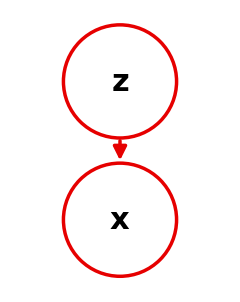

In [2]:
# Figure 15.4 の完全再現: 有向グラフィカルモデル
fig_15_4 = generate_figure_15_4(save_path='result/fig_15_4_gmm_graphical_model.png', show=True)


## 2. 事後確率としての負担率 (Responsibilities)

観測データ $\mathbf{x}$ が与えられたとき、「このデータ点が第 $k$ 成分から生成された確率」はベイズの定理によって計算できます。
この事後確率 (posterior probability) は**負担率 (responsibility)** $\gamma(z_k)$ と呼ばれ、モデルにおいて中心的な役割を果たします (テキスト式 15.10)：

$$\gamma(z_k) \equiv p(z_k = 1 \mid \mathbf{x}) = \frac{p(z_k = 1) p(\mathbf{x} \mid z_k = 1)}{\sum_{j=1}^K p(z_j = 1) p(\mathbf{x} \mid z_j = 1)} = \frac{\pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)} \tag{15.10}$$

負担率は以下の性質を持ちます：
1. **正規化**: 任意のデータ点 $\mathbf{x}$ に対し、$\sum_{k=1}^K \gamma(z_k) = 1$
2. **確率値**: $0 \le \gamma(z_k) \le 1$
3. **ソフトな割当**: K-means の二値割当 $r_{nk} \in \{0, 1\}$ と異なり、$[0, 1]$ の連続値をとるため、境界領域での不確実性を定量化できる。

### 3成分混合ガウス分布での完全データ・不完全データ・負担率可視化 (Figure 15.5)
合成データセット（$K=3$、$\pi = (0.5, 0.3, 0.2)$、計1,000点）を用いて：
- **(a) 完全データ (Complete data)**: 潜在変数 $\mathbf{z}_n$ の正解ラベルが観測できている状態（赤、緑、青で色分け）。
- **(b) 不完全データ (Incomplete data)**: 実際の観測状態。潜在ラベルが隠蔽されているため全データ点が同一色（マゼンタ）。
- **(c) 負担率の可視化**: 各データ点を 3次元の事後確率ベクトル $\boldsymbol{\gamma}_n = (\gamma_{n1}, \gamma_{n2}, \gamma_{n3})$ をそのまま RGB 色相ベクトルとして彩色。クラスタ重複領域での美しい混色（赤と緑の境目は黄色/茶色、緑と青の境目はシアン/青緑）が観察されます。


Total samples: 1000
Mixing coefficients (weights): [0.5 0.3 0.2]
Means:
[[0.188 0.386]
 [0.505 0.494]
 [0.779 0.589]]


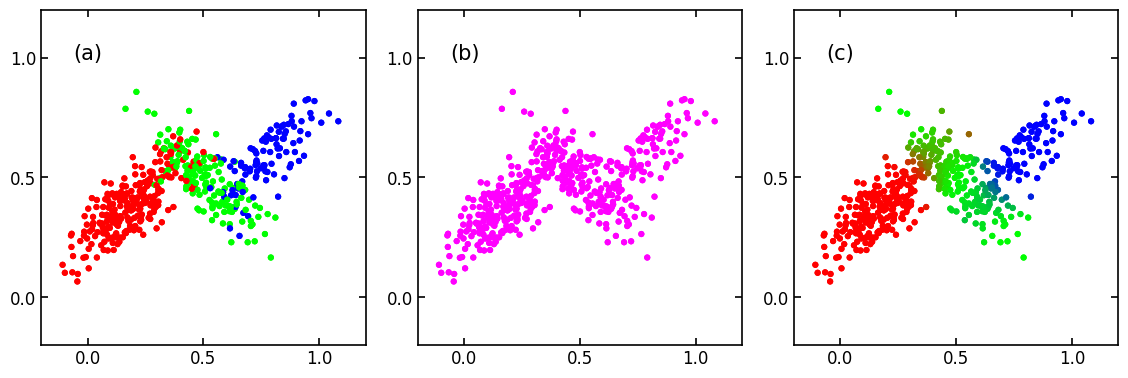

In [3]:
# 合成データの読み込みとパラメータ確認
X, clusters, params = load_gmm_synthetic_dataset()
print(f"Total samples: {len(X)}")
print(f"Mixing coefficients (weights): {params['weights']}")
print(f"Means:\n{params['means']}")

# Figure 15.5 の完全再現
fig_15_5 = generate_figure_15_5(save_path='result/fig_15_5_gmm_responsibilities.png', show=True)


## 3. 第15.2.1項 尤度関数 (Likelihood function)

独立同分布 (i.i.d.) に従う $N$ 個の観測データセット $\mathbf{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する尤度関数は各点での密度の積となります：

$$p(\mathbf{X} \mid \boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \prod_{n=1}^N \left\{ \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \right\}$$

両辺の自然対数をとることで、**対数尤度関数 (log-likelihood function)** が得られます (テキスト式 15.11)：

$$\ln p(\mathbf{X} \mid \boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \sum_{n=1}^N \ln \left\{ \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \right\} \tag{15.11}$$

### 単一ガウス分布との決定的な相違点
単一のガウス分布では、対数尤度関数は $\sum_n \ln \mathcal{N}(\mathbf{x}_n)$ となり、対数が指数関数 $\exp(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu}))$ を直接相殺するため、二乗形式の簡単な和となり、解析的な最尤解（標本平均と標本分散）が得られました。

しかし混合ガウスモデルでは、**対数の内側に総和記号 $\sum_k$ が入っている**ため、対数と指数が相殺されません。
この「和の対数 (log of sum)」の構造こそが、最尤解の閉じた解析的導出を不可能にし、複雑な非凸最適化問題をもたらす根源です。


## 4. 第15.2.2項 最尤推定 (Maximum likelihood) とその課題

混合ガウスモデルの最尤推定には、単一ガウスには存在しない深刻な数学的・計算的課題が伴います。

### 1. 尤度関数の特異点問題 (Singularities)
混合ガウス分布の最尤推定において最も重大な問題は、**尤度関数が上に非有界 (unbounded above)** であるという事実です。

1次元の混合ガウス分布を考え、ある成分 $j$ の平均が特定のデータ点 $\mathbf{x}_n$ に完全に一致したとします ($\mu_j = x_n$)。
このとき、その成分の分散 $\sigma_j^2 \to 0$ の極限を考えると：

$$\mathcal{N}(x_n \mid x_n, \sigma_j^2) = \frac{1}{(2\pi)^{1/2} \sigma_j} \to \infty$$

他のデータ点 $x_{m \neq n}$ に対する密度が他の成分によって正の有限値に保たれている限り、全体の対数尤度は：

$$\ln p(\mathbf{X}) \to +\infty$$

すなわち、対数尤度関数の地形には **高さ無限大の針のような特異点（スパイク）** がデータ点ごとに無数に存在します。
したがって、大域的な最大尤度を愚直に探索すると、1つのガウス成分が1つのデータ点に潰れて分散がゼロになるという病的な解（オーバーフィッティングの極限）に捕らわれてしまいます。


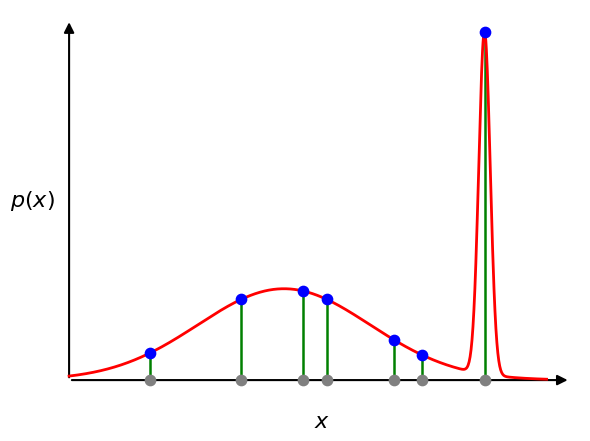

In [4]:
# Figure 15.6 の完全再現: 尤度関数の特異点 (Singularity in Likelihood)
fig_15_6 = generate_figure_15_6(save_path='result/fig_15_6_likelihood_singularity.png', show=True)


### Figure 15.6 の解説
- 赤い曲線: 全体密度 $p(x) = \pi_1 \mathcal{N}(x \mid \mu_1, \sigma_1^2) + \pi_2 \mathcal{N}(x \mid \mu_2, \sigma_2^2)$
- 灰色の点: 水平軸上のデータ点 $x_n$
- 緑の縦線と青の丸: 各データ点での確率密度値 $p(x_n)$
- 左側の幅の広いガウス成分が大多数のデータを説明している一方、右端のデータ点上に $\sigma_2 \to 0$ となる成分が崩壊して**極めて鋭く巨大なスパイク（特異点）** を形成しています。
- **対処法**: 共分散の対角成分に微小正定数 $\epsilon \mathbf{I}$ を加える正則化を行うか、共分散行列に対して事前分布（逆ウィシャート分布など）を導入するMAP推定・ベイズ学習を行います。

---

### 2. パラメータの識別不可能性 (Identifiability / Label Switching)
$K$ 個の成分をもつ混合モデルでは、成分のインデックス（ラベル）を任意に入れ替えても同一の確率分布が得られます。
そのため、パラメータ空間には $K!$ 個の等価な峰（モード）が存在します。これは**ラベル・スイッチング問題**として知られます。

---

### 3. 最尤推定の停留条件の導出

対数尤度関数 $\ln p(\mathbf{X})$ を最大化するパラメータの条件を求めるため、各パラメータに関する微分をゼロとおきます。

#### (A) 平均 $\boldsymbol{\mu}_k$ の停留条件
対数尤度を $\boldsymbol{\mu}_k$ で偏微分します：

$$\frac{\partial \ln p(\mathbf{X})}{\partial \boldsymbol{\mu}_k} = \sum_{n=1}^N \frac{1}{\sum_j \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)} \cdot \pi_k \frac{\partial \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\partial \boldsymbol{\mu}_k}$$

ここで、ガウス関数の微分は $\frac{\partial \mathcal{N}}{\partial \boldsymbol{\mu}_k} = \mathcal{N} \cdot \boldsymbol{\Sigma}_k^{-1} (\mathbf{x}_n - \boldsymbol{\mu}_k)$ です。
負担率 $\gamma(z_{nk})$ の定義式 (15.10) を代入すると、驚くほど簡潔な形になります：

$$\frac{\partial \ln p(\mathbf{X})}{\partial \boldsymbol{\mu}_k} = \sum_{n=1}^N \gamma(z_{nk}) \boldsymbol{\Sigma}_k^{-1} (\mathbf{x}_n - \boldsymbol{\mu}_k) = 0$$

両辺に $\boldsymbol{\Sigma}_k$ を掛けて展開すると：

$$\sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n - \boldsymbol{\mu}_k \sum_{n=1}^N \gamma(z_{nk}) = 0$$

クラスタ $k$ に割り当てられた**実効データ点数 (effective number of points)** を次のように定義します (テキスト式 15.13)：

$$N_k \equiv \sum_{n=1}^N \gamma(z_{nk}) \tag{15.13}$$

これにより、平均の停留解が得られます (テキスト式 15.14)：

$$\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n \tag{15.14}$$

幾何学的な意味: 新しい平均は、全データ点を負担率 $\gamma(z_{nk})$ で重み付けした加重平均 (weighted mean) です！
K-means の式 (15.3) と比較すると、二値割当 $r_{nk}$ が連続の事後確率 $\gamma(z_{nk})$ に置き換わっていることが分かります。

#### (B) 共分散 $\boldsymbol{\Sigma}_k$ の停留条件
同様に $\boldsymbol{\Sigma}_k$ について偏微分してゼロとおくことで、加重共分散行列が得られます (テキスト式 15.15)：

$$\boldsymbol{\Sigma}_k = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) (\mathbf{x}_n - \boldsymbol{\mu}_k)(\mathbf{x}_n - \boldsymbol{\mu}_k)^T \tag{15.15}$$

#### (C) 混合係数 $\pi_k$ の停留条件
混合係数は制約 $\sum_{k=1}^K \pi_k = 1$ を満たす必要があるため、ラグランジュ未定乗数法を用います。ラグランジュ関数は：

$$\mathcal{L}(\boldsymbol{\pi}, \lambda) = \ln p(\mathbf{X}) + \lambda \left( \sum_{k=1}^K \pi_k - 1 \right) \tag{15.16}$$

$\pi_k$ で微分してゼロとおきます：

$$\frac{\partial \mathcal{L}}{\partial \pi_k} = \sum_{n=1}^N \frac{\mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_j \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)} + \lambda = 0$$

両辺に $\pi_k$ を掛けると、左辺の和は負担率 $\gamma(z_{nk})$ となります：

$$\sum_{n=1}^N \gamma(z_{nk}) + \lambda \pi_k = 0 \iff N_k + \lambda \pi_k = 0$$

すべての $k=1, \dots, K$ について総和をとると：

$$\sum_{k=1}^K N_k + \lambda \sum_{k=1}^K \pi_k = 0 \implies N + \lambda (1) = 0 \implies \lambda = -N$$

これを代入すると、混合係数の停留条件が得られます (テキスト式 15.18)：

$$\pi_k = \frac{N_k}{N} \tag{15.18}$$

実効データ点数 $N_k$ の全データ数 $N$ に対する割合に一致します！


## 5. 循環依存性とEMアルゴリズムへの橋渡し

得られた停留条件 (15.14), (15.15), (15.18) をもう一度見直してみましょう：
- $\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) \mathbf{x}_n$
- $\boldsymbol{\Sigma}_k = \frac{1}{N_k} \sum_{n=1}^N \gamma(z_{nk}) (\mathbf{x}_n - \boldsymbol{\mu}_k)(\mathbf{x}_n - \boldsymbol{\mu}_k)^T$
- $\pi_k = \frac{N_k}{N}$

これらは一見するとパラメータの閉じた解析解のように見えますが、**右辺に含まれる負担率 $\gamma(z_{nk})$ 自体がパラメータ $\{\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Sigma}\}$ に依存しています** (式 15.10)：

$$\gamma(z_{nk}) = \frac{\pi_k \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

すなわち：
1. パラメータが分かれば、負担率を計算できる。
2. 負担率が分かれば、パラメータを計算できる。

この**「鶏と卵」の循環的関係**は、次節（15.3節）で詳述する強力な一般枠組み**EMアルゴリズム (Expectation–Maximization Algorithm)** の反復手続きを自然に示唆しています：
- **Eステップ**: 現在のパラメータを用いて負担率 $\gamma(z_{nk})$ を推定する。
- **Mステップ**: 求めた負担率を用いてパラメータ $\{\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Sigma}\}$ を更新する。


Convergence after 25 iterations.
Learned mixing coefficients:
  Component 0: weight = 0.184, mean = [0.787 0.6  ]
  Component 1: weight = 0.492, mean = [0.184 0.382]
  Component 2: weight = 0.324, mean = [0.51  0.494]


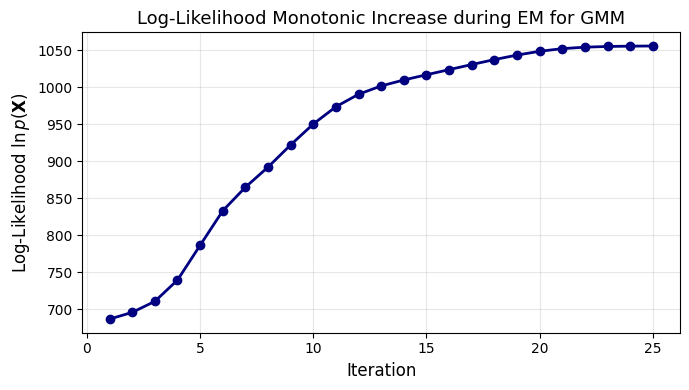

In [5]:
# GMM による学習と対数尤度の単調増加の数値的確認
gmm_fitted = GaussianMixtureModel(n_components=3, max_iter=25, random_state=42)
gmm_fitted.fit(X)

print(f"Convergence after {gmm_fitted.n_iter_} iterations.")
print("Learned mixing coefficients:")
for k in range(3):
    print(f"  Component {k}: weight = {gmm_fitted.weights_[k]:.3f}, mean = {gmm_fitted.means_[k].round(3)}")

# 対数尤度の推移
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(gmm_fitted.history_log_likelihood_) + 1), gmm_fitted.history_log_likelihood_, 'o-', color='navy', lw=2)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel(r"Log-Likelihood $\ln p(\mathbf{X})$", fontsize=12)
plt.title("Log-Likelihood Monotonic Increase during EM for GMM", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. 第15.2節のまとめ

本節では、離散潜在変数モデルとしての混合ガウス分布の基礎理論と最尤推定の課題を学びました：

1. **混合ガウス分布 (式 15.5)**: $K$ 個のガウス成分の線形重ね合わせ。
2. **潜在変数 $\mathbf{z}$ (式 15.8 - 15.9)**: 1-of-$K$ 表現による生成モデルと有向グラフィカルモデル (Figure 15.4)。
3. **負担率 $\gamma(z_{nk})$ (式 15.10)**: ベイズ事後確率によるソフトな割当とRGB色相ブレンディング (Figure 15.5)。
4. **対数尤度関数 (式 15.11)**: 「和の対数」による解析解の困難。
5. **最尤推定の課題**:
   - **特異点問題 (Figure 15.6)**: 1つの成分が1点に崩壊したときの尤度発散 $\ln p \to +\infty$。
   - **識別不可能性**: $K!$ 個のラベル置換対称性。
6. **停留条件 (式 15.13 - 15.18)**: 負担率による加重平均・加重共分散・実効点数比率。

次節（15.3節）では、この停留条件を基盤として、一般の潜在変数モデルに対する最適化フレームワークである **EMアルゴリズム (Expectation–Maximization Algorithm)** の数学的性質、変分下界 (Evidence Lower Bound, ELBO) の最大化、KLダイバージェンスとの幾何学的関係、および K-means との厳密な漸近関係について探求します。
